# 1 Inequality in Denmark

In [37]:
# Imprts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dstapi import DstApi

# Download IFOR41 with DStAPI
api41 = DstApi('IFOR41')

params41 = {
    'table': 'IFOR41',
    'format': 'BULK',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

gini_raw = api41.get_data(params=params41)

gini_raw = gini_raw[["KOMMUNEDK", "TID", "INDHOLD"]].copy()
gini_raw.columns = ["municipality", "Year", "Gini"]

gini_raw["municipality"] = gini_raw["municipality"].astype(str)
gini_raw["Year"] = pd.to_numeric(gini_raw["Year"], errors="coerce")
gini_raw["Gini"] = pd.to_numeric(
    gini_raw["Gini"].astype(str).str.replace(",", "."),
    errors="coerce"
)
gini_raw = gini_raw.dropna().sort_values(["municipality", "Year"]).reset_index(drop=True)

# Download IFOR32 with DStAPI
api32 = DstApi('IFOR32')

params32 = {
    'table': 'IFOR32',
    'format': 'BULK',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

decile_raw = api32.get_data(params=params32)

decile_raw = decile_raw[["KOMMUNEDK", "DECILGEN", "TID", "INDHOLD"]].copy()
decile_raw.columns = ["municipality", "decile", "Year", "income"]

decile_raw["municipality"] = decile_raw["municipality"].astype(str)
decile_raw["Year"] = pd.to_numeric(decile_raw["Year"], errors="coerce")
decile_raw["income"] = pd.to_numeric(
    decile_raw["income"].astype(str).str.replace(",", "."),
    errors="coerce"
)
decile_raw["decile"] = decile_raw["decile"].astype(str).str.extract(r"(\d+)")
decile_raw["decile"] = pd.to_numeric(decile_raw["decile"], errors="coerce")
decile_raw = decile_raw.dropna().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)


### 1.1 The Gini coefficient and the top 10 percent share

We use IFOR41 to plot the Gini coefficient for Denmark over time. The figure shows how overall income inequality has developed since 1987. The Gini coefficient has fluctuated over the period, but there is a clear overall upward trend.

We use IFOR32 to compute the share of total income going to the richest 10 percent. Since each decile contains the same number of individuals, the top 10 percent income share is

$$
\text{top 10\% share}
=
\frac{\bar{y}_{10}}
{\sum_{d=1}^{10}\bar{y}_d}.
$$

The Gini coefficient and the top 10 percent income share move closely together over time. The correlation between the two measures is 0.982, indicating a very strong positive relationship.

Thus, the two measures tell broadly the same story: income inequality in Denmark has increased over the period. However, the Gini coefficient measures inequality across the entire income distribution, while the top 10 percent share focuses specifically on the upper part of the distribution.

Correlation: 0.982


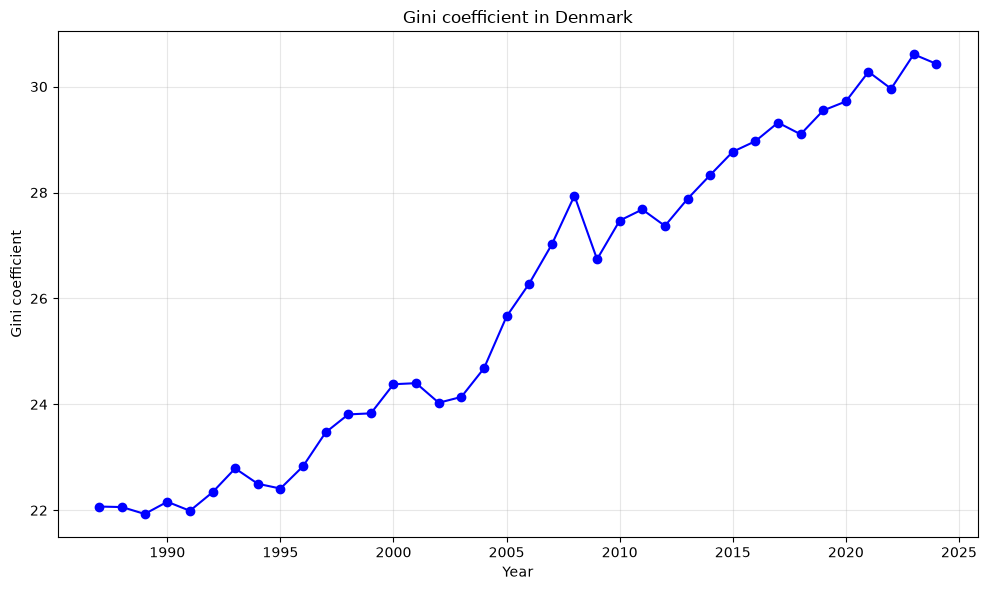

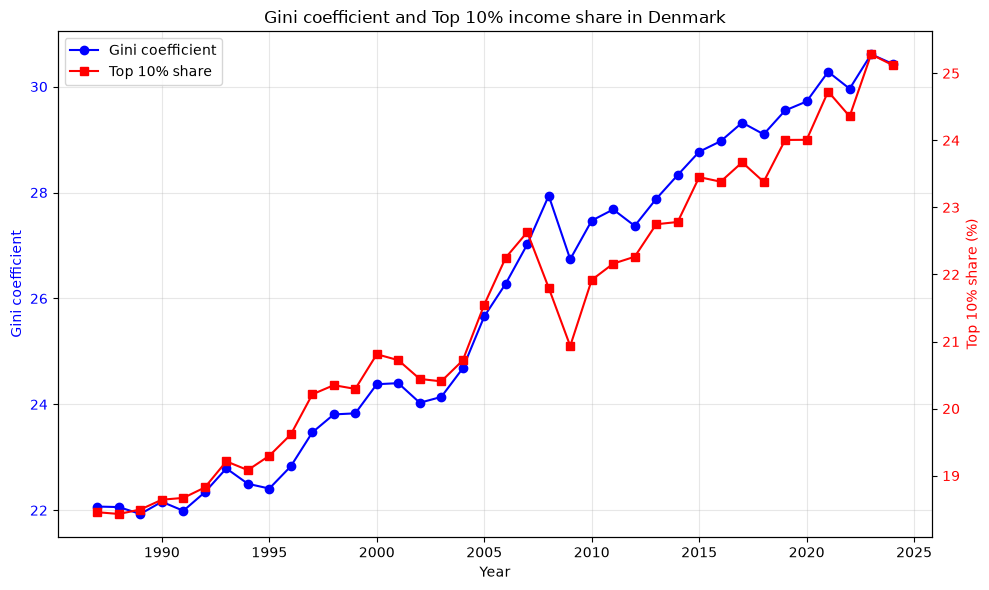

In [47]:
# National data: keep only "Hele landet"
gini_nat = gini_raw[
    gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values("Year").reset_index(drop=True)

decile_nat = decile_raw[
    decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["Year", "decile"]).reset_index(drop=True)

decile_pivot = decile_nat.pivot_table(
    index="Year",
    columns="decile",
    values="income",
    aggfunc="first"
).sort_index()

decile_pivot = decile_pivot.reindex(columns=range(1, 11), fill_value=np.nan)
top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)

top10 = top10_share.reset_index()
top10.columns = ["Year", "Top10Share"]

merged = gini_nat.merge(top10, on="Year", how="inner")

# Compute correlation between Gini and top 10% share
corr = merged["Gini"].corr(merged["Top10Share"])

print(f"Correlation: {corr:.3f}")

# Figure 1: Gini coefficient over time
plt.figure(figsize=(10, 6))
plt.plot(merged["Year"], merged["Gini"], color="blue", marker="o")
plt.title("Gini coefficient in Denmark")
plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Gini and top 10% share in the same figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gini coefficient
line1 = ax1.plot(
    merged["Year"],
    merged["Gini"],
    color="blue",
    marker="o",
    label="Gini coefficient"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True, alpha=0.3)

# Top 10% income share
ax2 = ax1.twinx()

line2 = ax2.plot(
    merged["Year"],
    merged["Top10Share"] * 100,
    color="red",
    marker="s",
    label="Top 10% share"
)

ax2.set_ylabel("Top 10% share (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combine both lines in one legend
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left")

plt.title("Gini coefficient and Top 10% income share in Denmark")
fig.tight_layout()
plt.show()

### 1.2 Prediction
The coefficients obtained with `scipy.optimize.minimize` are approximately the same as those obtained with `np.polyfit`.

The linear model predicts a Gini coefficient of 32.375 in 2030 and 35.011 in 2040. The quadratic model predicts 32.941 in 2030 and 36.271 in 2040.

The difference between the two predictions is 0.566 in 2030 and 1.260 in 2040. Both models fit the historical data reasonably well, although the quadratic model allows for more curvature.

The predictions become more different further into the future. We would therefore be cautious about using either model as a long-run forecast, since both models simply extend the historical trend and do not account for future economic or institutional changes.

Linear coefficients:
beta0 = 21.0428
beta1 = 0.2635
Quadratic coefficients:
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178
Linear coefficients: 0.264, 21.043
Quadratic coefficients: 0.001, 0.220, 21.304
Year 2030: linear = 32.375, quadratic = 32.941
Year 2040: linear = 35.011, quadratic = 36.271


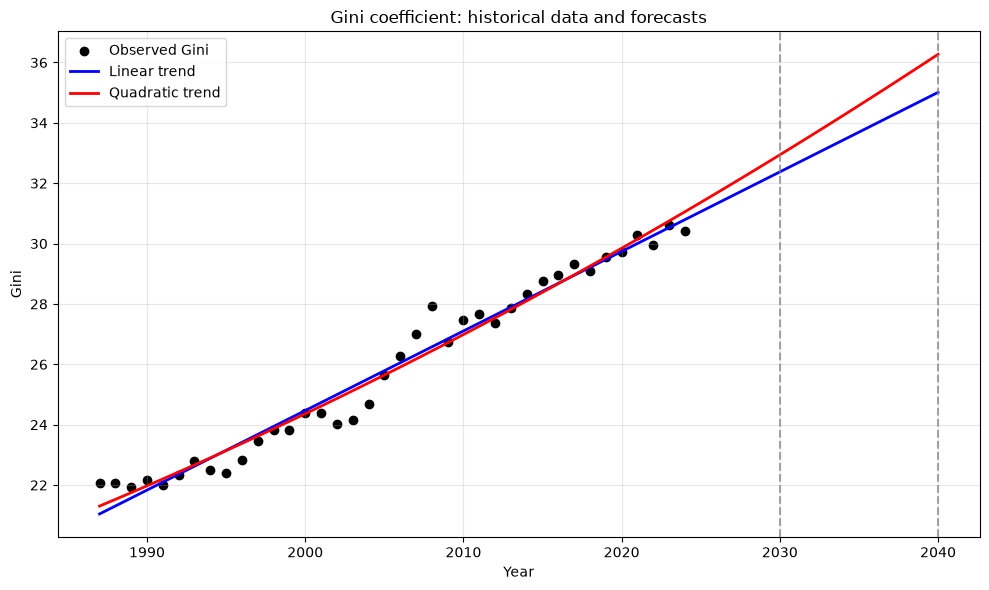

In [39]:
# Minimize SSE with scipy.optimize.minimize
gini_fit = gini_nat.copy()
gini_fit["t"] = gini_fit["Year"] - gini_fit["Year"].min()

t = gini_fit["t"].to_numpy()
y = gini_fit["Gini"].to_numpy()

# Linear trend
def sse_linear(beta, t, y):
    y_hat = beta[0] + beta[1] * t
    return np.sum((y - y_hat) ** 2)

result_linear = minimize(
    sse_linear,
    x0=[20, 0.1],
    args=(t, y)
)

beta_linear = result_linear.x
print("Linear coefficients:")
print(f"beta0 = {beta_linear[0]:.4f}")
print(f"beta1 = {beta_linear[1]:.4f}")

# Quadratic trend
def sse_quadratic(beta, t, y):
    y_hat = beta[0] + beta[1] * t + beta[2] * t**2
    return np.sum((y - y_hat) ** 2)

result_quadratic = minimize(
    sse_quadratic,
    x0=[20, 0.1, 0.001],
    args=(t, y)
)

beta_quadratic = result_quadratic.x
print("Quadratic coefficients:")
print(f"beta0 = {beta_quadratic[0]:.4f}")
print(f"beta1 = {beta_quadratic[1]:.4f}")
print(f"beta2 = {beta_quadratic[2]:.6f}")

# Minimize with polyfit
coef_lin = np.polyfit(t, y, 1)
coef_quad = np.polyfit(t, y, 2)

print(f"Linear coefficients: {coef_lin[0]:.3f}, {coef_lin[1]:.3f}")
print(f"Quadratic coefficients: {coef_quad[0]:.3f}, {coef_quad[1]:.3f}, {coef_quad[2]:.3f}")

# Forecasts for 2030 and 2040 with a for loop
for year in [2030, 2040]:
    tau = year - gini_fit["Year"].min()
    lin_pred = beta_linear[0] + beta_linear[1] * tau
    quad_pred = beta_quadratic[0] + beta_quadratic[1] * tau + beta_quadratic[2] * tau**2
    print(f"Year {year}: linear = {lin_pred:.3f}, quadratic = {quad_pred:.3f}")

# Plot observed data + fitted trends
years_future = np.arange(gini_fit["Year"].min(), 2041)
t_future = years_future - gini_fit["Year"].min()

linear_fit = beta_linear[0] + beta_linear[1] * t_future
quadratic_fit = beta_quadratic[0] + beta_quadratic[1] * t_future + beta_quadratic[2] * t_future**2

plt.figure(figsize=(10, 6))
plt.scatter(gini_fit["Year"], gini_fit["Gini"], color="black", label="Observed Gini")
plt.plot(years_future, linear_fit, color="blue", linewidth=2, label="Linear trend")
plt.plot(years_future, quadratic_fit, color="red", linewidth=2, label="Quadratic trend")
plt.axvline(2030, color="gray", linestyle="--", alpha=0.7)
plt.axvline(2040, color="gray", linestyle="--", alpha=0.7)
plt.title("Gini coefficient: historical data and forecasts")
plt.xlabel("Year")
plt.ylabel("Gini")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Municipalities

At the municipality level, we compute the correlation between the Gini coefficient and the top 10 percent share in the most recent year. This tells us whether municipalities with high overall inequality also have a large concentration of income at the top.

We then identify the 10 most unequal and the 10 least unequal municipalities and show them in a figure. The figure shows which municipalities are most and least unequal in the latest year. We also look at the municipalities with the largest and smallest change in the Gini coefficient over time, but we only interpret these rankings after checking the underlying time series, because a small population can make the Gini coefficient very sensitive to a single large income observation.

Correlation across municipalities in 2024: 0.975
Most unequal:
      municipality   Gini
24        Gentofte  49.04
73       Rudersdal  47.31
92           Vejen  46.32
43        Hørsholm  40.07
56  Lyngby-Taarbæk  39.28
20   Frederiksberg  36.54
50       København  34.97
2           Aarhus  33.43
18     Fredensborg  32.76
33       Helsingør  30.55

Most equal:
       municipality   Gini
14  Faaborg-Midtfyn  23.77
12           Egedal  23.85
8          Bornholm  24.03
17             Faxe  24.09
16         Favrskov  24.41
31          Halsnæs  24.41
5            Assens  24.46
32        Hedensted  24.58
3       Albertslund  24.66
65            Odder  24.70


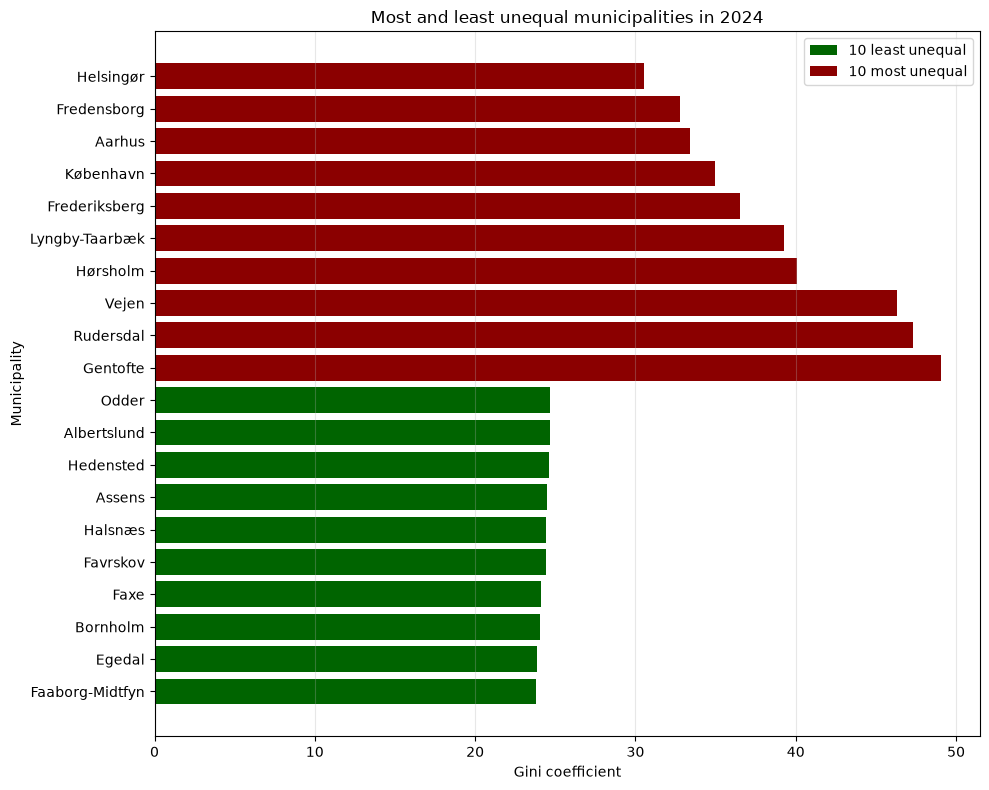


Largest increase in Gini:
      municipality  gini_first  gini_last  change
92           Vejen       21.20      46.32   25.12
73       Rudersdal       29.05      47.31   18.26
24        Gentofte       31.10      49.04   17.94
56  Lyngby-Taarbæk       24.97      39.28   14.31
50       København       23.05      34.97   11.92
43        Hørsholm       28.39      40.07   11.68
18     Fredensborg       21.17      32.76   11.59
2           Aarhus       22.10      33.43   11.33
20   Frederiksberg       25.28      36.54   11.26
90      Vallensbæk       15.90      26.70   10.80

Smallest change in Gini:
       municipality  gini_first  gini_last  change
15             Fanø       25.67      26.34    0.67
97              Ærø       24.63      26.98    2.35
17             Faxe       21.64      24.09    2.45
57             Læsø       22.81      25.41    2.60
8          Bornholm       21.31      24.03    2.72
14  Faaborg-Midtfyn       20.88      23.77    2.89
81             Sorø       22.24      25.

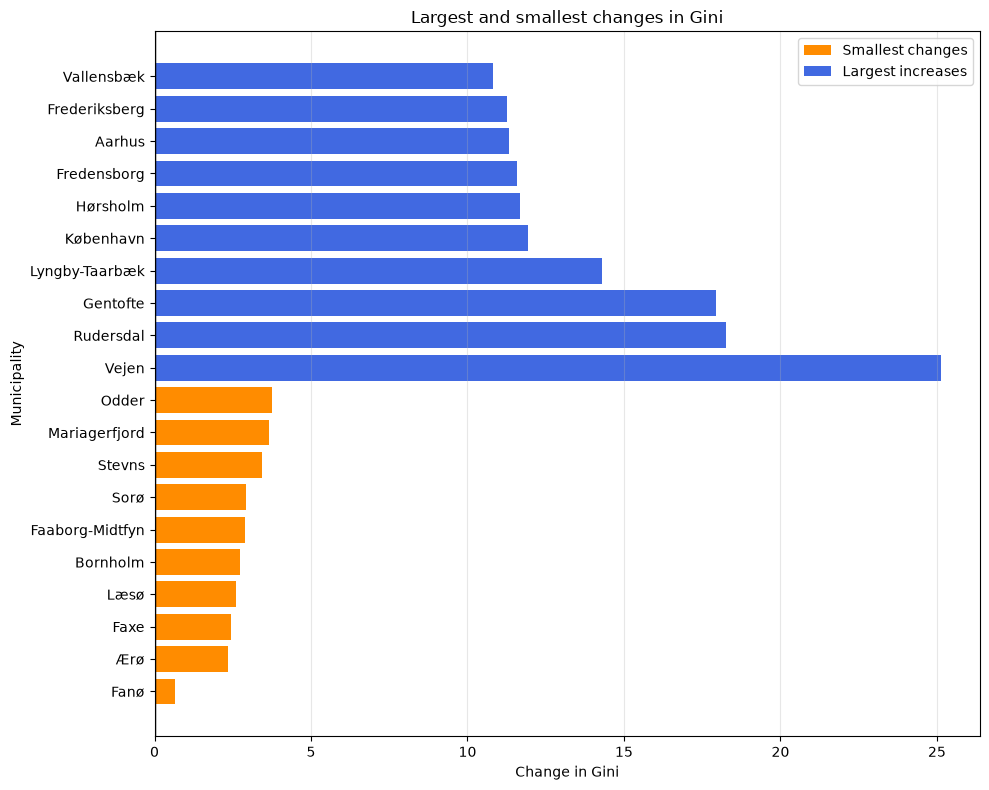

In [40]:
# Reuse the already cleaned raw data and filter out the national aggregate
gini = gini_raw[
    ~gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year"]).reset_index(drop=True)

decile = decile_raw[
    ~decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)

# 2) Top 10% share
decile_pivot = decile.pivot_table(
    index=["municipality", "Year"],
    columns="decile",
    values="income",
    aggfunc="first"
).reindex(columns=range(1, 11), fill_value=np.nan)

top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)
top10 = top10_share.reset_index()
top10.columns = ["municipality", "Year", "Top10Share"]

# 3) Latest year and correlation across municipalities
latest_year = max(gini["Year"].max(), top10["Year"].max())
gini_latest = gini[gini["Year"] == latest_year].copy()
top10_latest = top10[top10["Year"] == latest_year].copy()

df = gini_latest.merge(top10_latest, on=["municipality", "Year"], how="inner")

corr = df["Gini"].corr(df["Top10Share"])
print(f"Correlation across municipalities in {latest_year}: {corr:.3f}")

# 4) Most unequal / most equal municipalities in the most recent year
most_unequal = df.sort_values("Gini", ascending=False).head(10).copy()
most_equal = df.sort_values("Gini", ascending=True).head(10).copy()

print("Most unequal:")
print(most_unequal[["municipality", "Gini"]])

print("\nMost equal:")
print(most_equal[["municipality", "Gini"]])

fig, ax = plt.subplots(figsize=(10, 8))

# 10 least unequal municipalities
ax.barh(
    most_equal["municipality"],
    most_equal["Gini"],
    color="darkgreen",
    label="10 least unequal"
)

# 10 most unequal municipalities
ax.barh(
    most_unequal["municipality"],
    most_unequal["Gini"],
    color="darkred",
    label="10 most unequal"
)

ax.set_title(f"Most and least unequal municipalities in {latest_year}")
ax.set_xlabel("Gini coefficient")
ax.set_ylabel("Municipality")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 5) Largest and smallest change in Gini over time
gini_change = (
    gini.groupby("municipality")
    .agg(gini_first=("Gini", "first"), gini_last=("Gini", "last"))
    .reset_index()
)
gini_change["change"] = gini_change["gini_last"] - gini_change["gini_first"]

largest_change = gini_change.sort_values("change", ascending=False).head(10)
smallest_change = gini_change.sort_values("change", ascending=True).head(10)

print("\nLargest increase in Gini:")
print(largest_change[["municipality", "gini_first", "gini_last", "change"]])

print("\nSmallest change in Gini:")
print(smallest_change[["municipality", "gini_first", "gini_last", "change"]])

# Plot largest and smallest changes in the same figure
fig, ax = plt.subplots(figsize=(10, 8))

# Smallest changes
ax.barh(
    smallest_change["municipality"],
    smallest_change["change"],
    color="darkorange",
    label="Smallest changes"
)

# Largest increases
ax.barh(
    largest_change["municipality"],
    largest_change["change"],
    color="royalblue",
    label="Largest increases"
)

# Line showing no change
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Largest and smallest changes in Gini")
ax.set_xlabel("Change in Gini")
ax.set_ylabel("Municipality")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4 Extension

As an extension, we add another municipality-level variable and relate it to the Gini coefficient or to its change over time. The purpose is to see whether inequality is associated with other local characteristics, such as unemployment, education, or other demographic and economic differences across municipalities.

the municipality-level correlation is very strong and positive, which matches the national pattern over time. The unequal municipalities are mainly wealthy suburban municipalities, while the more equal ones tend to be smaller or less affluent municipalities. The largest changes mostly reflect municipal changes over time rather than one-off extreme incomes, so the time-series plots are important for checking whether a ranking is driven by a single unusually large income year.

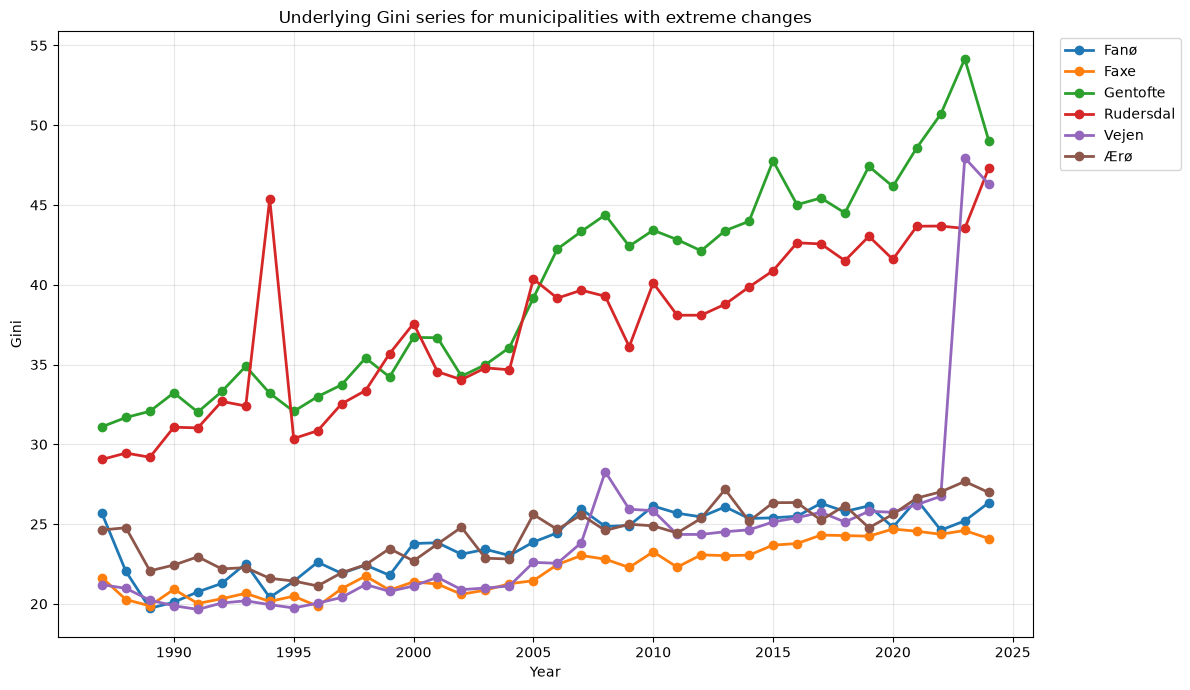

In [41]:
# Also inspect the underlying series for the municipalities with the largest/smallest changes
selected_change_municipalities = list(largest_change["municipality"].head(3)) + list(smallest_change["municipality"].head(3))
change_series_selected = gini[gini["municipality"].isin(selected_change_municipalities)].copy()

fig, ax = plt.subplots(figsize=(12, 7))
for muni, grp in change_series_selected.groupby("municipality"):
    ax.plot(grp["Year"], grp["Gini"], marker="o", linewidth=2, label=muni)
ax.set_title("Underlying Gini series for municipalities with extreme changes")
ax.set_xlabel("Year")
ax.set_ylabel("Gini")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2 Simulating the income distribution

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib.util
import pathlib
import sys

# Load the original model from the existing file
src_path = pathlib.Path('Income_model.py')
spec = importlib.util.spec_from_file_location('model_2_1', str(src_path))
module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = module
spec.loader.exec_module(module)
simulate_income_model = module.simulate_income_model

### 2.2 Simulate the income distribution

The education shares match the target probabilities, so the initial composition is correctly calibrated.
The unemployment rate settles near the theoretical steady-state value s / (s + f).
Income rises over the life cycle and the right tail becomes thicker at older ages, so the distribution becomes more dispersed and more skewed.

Income shape: (50000, 48)
0 0.39988
1 0.35166
2 0.24846
Unemployment rate at age 65: 0.0769
Theoretical steady state: 0.07692307692307693
Theoretical steady-state unemployment rate: 0.077
Average unemployment rate for ages >= 25: 0.078


/var/folders/z0/p4fwt95141vf942nxl1b2d_80000gn/T/ipykernel_12034/1704425906.py:17: RuntimeWarning: invalid value encountered in divide
  unemployed.sum(axis=0) / labor_force.sum(axis=0)


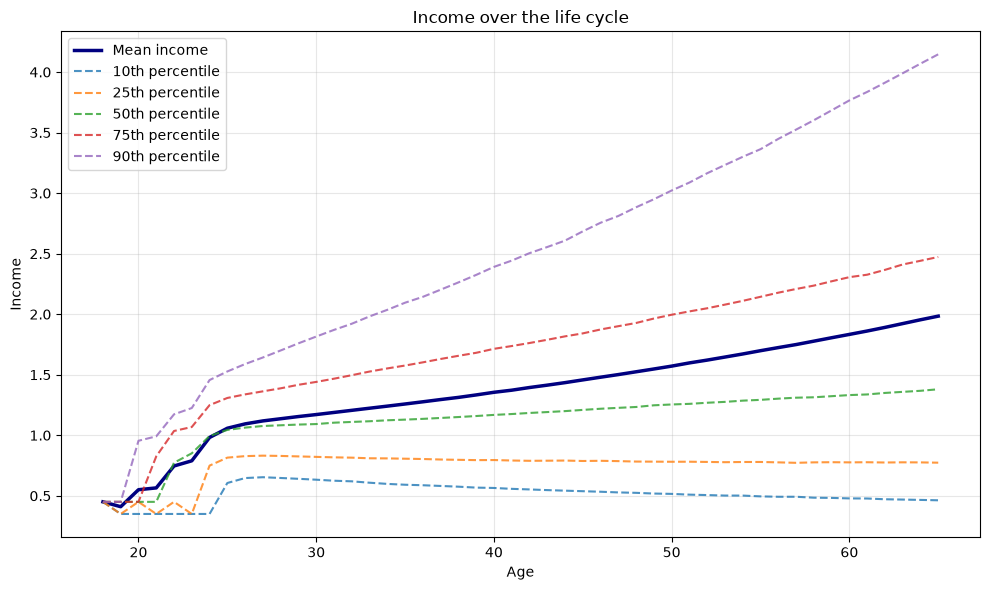

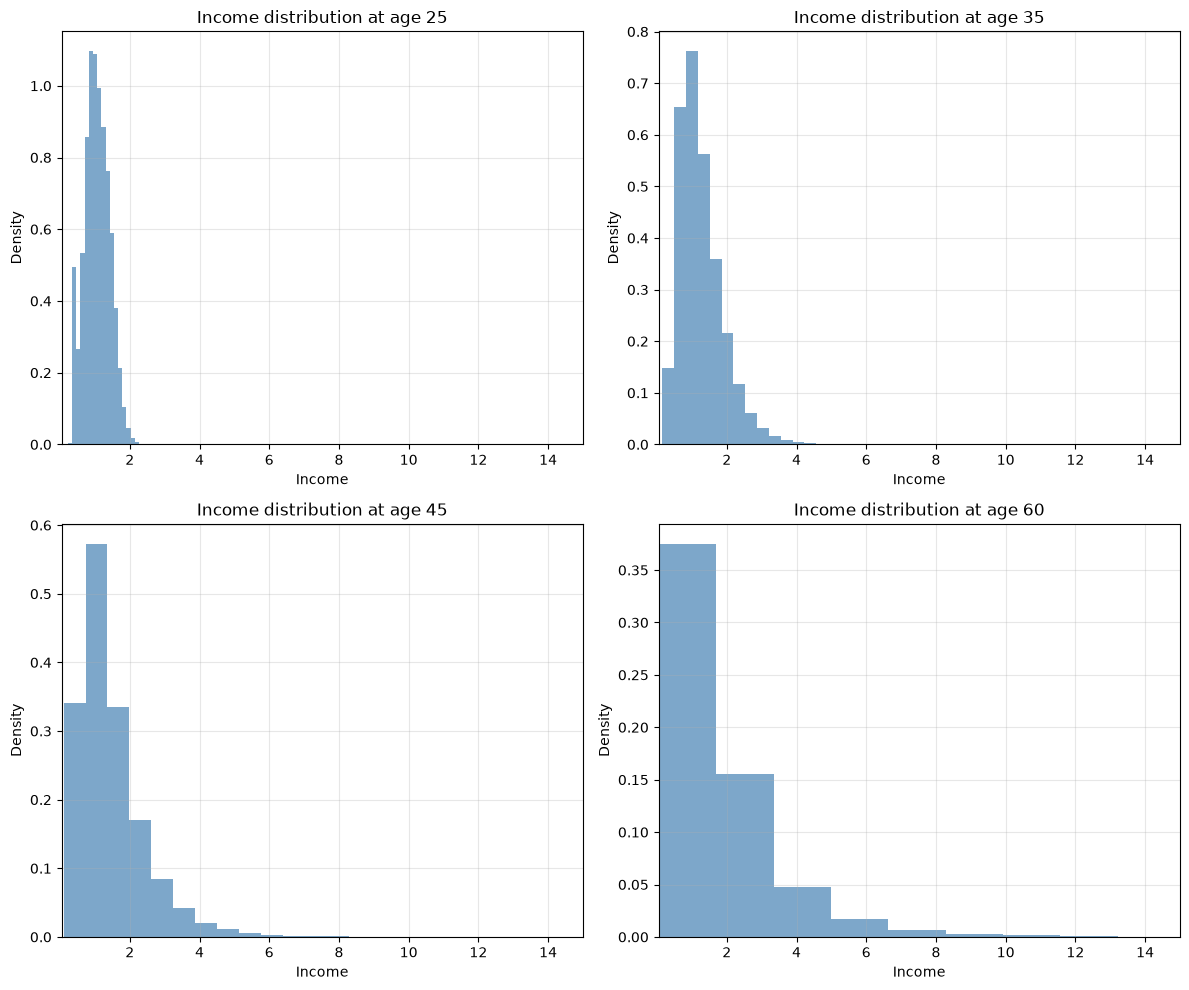

In [43]:
sim = simulate_income_model(seed=1234)
ages = sim['ages']
income = sim['income']
education = sim['education']
employed = sim['employed']
labor_force = sim['labor_force']

# Vores checks
print("Income shape:", income.shape)

for e in range(3):
    share = np.mean(education == e)
    print(e, share)

unemployed = labor_force & ~employed
unemployment_by_age = (
    unemployed.sum(axis=0) / labor_force.sum(axis=0)
)

steady_state = 0.05 / (0.05 + 0.60)

print("Unemployment rate at age 65:", unemployment_by_age[-1])
print("Theoretical steady state:", steady_state)

job_finding = 0.60
job_separation = 0.05
steady_state_u = job_separation / (job_separation + job_finding)
print(f'Theoretical steady-state unemployment rate: {steady_state_u:.3f}')
print(f'Average unemployment rate for ages >= 25: {np.nanmean(unemployment_by_age[ages >= 25]):.3f}')

# 2.2.2 Plot mean and selected percentiles of income over the life cycle
mean_income = income.mean(axis=0)
percentiles = [10, 25, 50, 75, 90]
percentile_income = np.percentile(income, percentiles, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ages, mean_income, color='navy', linewidth=2.5, label='Mean income')
for p, values in zip(percentiles, percentile_income):
    ax.plot(ages, values, linestyle='--', alpha=0.8, label=f'{p}th percentile')
ax.set_title('Income over the life cycle')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2.2.3 Histogram of the income distribution at selected ages
selected_ages = [25, 35, 45, 60]
selected_idx = [np.argmin(np.abs(ages - age)) for age in selected_ages]

# Set common x-axis limits
income_min = income.min()
income_max = income.max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, age, idx in zip(axes, selected_ages, selected_idx):
    income_at_age = income[:, idx]
    ax.hist(income_at_age, bins=20, density=True, alpha=0.7, color='steelblue')
    ax.set_title(f'Income distribution at age {age}')
    ax.set_xlabel('Income')
    ax.set_ylabel('Density')
    ax.set_xlim(income_min, 15)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 2.3 Compute the Gini coefficient and plot the Lorenz curve

Inequality is usually lower within a single age group than in the pooled sample, because pooling adds age differences in human capital and labor-market status.

Gini of uniform [0,1]: 0.333367
Gini coefficient for the full simulated sample: 0.373


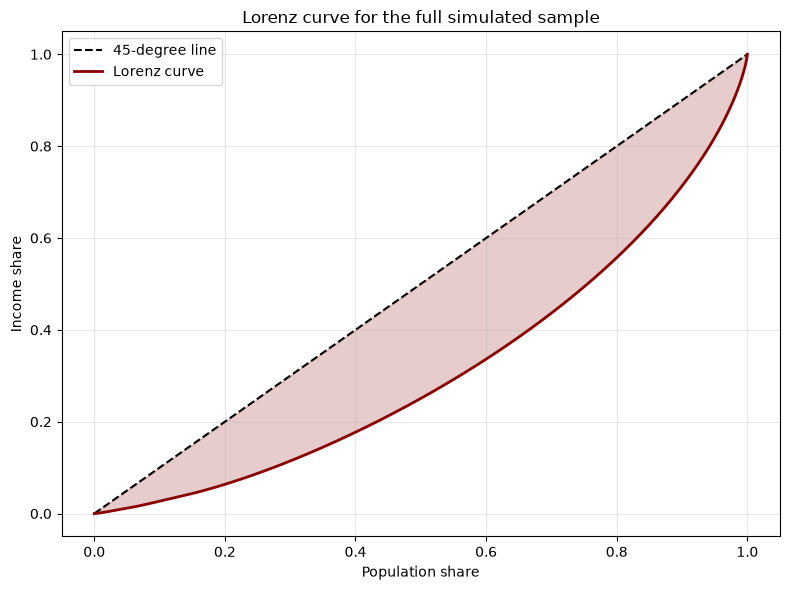

Gini by age:
  Age 25: 0.191
  Age 35: 0.267
  Age 45: 0.338
  Age 60: 0.425
Pooled Gini: 0.373


In [44]:
def gini(x):
    x = np.asarray(x, dtype=float).ravel()
    if x.size == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    idx = np.arange(1, n + 1)
    return float(2 * np.sum(idx * x) / (n * np.sum(x)) - (n + 1) / n)

# Check the function on a known case
uniform_draws = np.linspace(0, 1, 10000)
print(f'Gini of uniform [0,1]: {gini(uniform_draws):.6f}')

pooled_gini = gini(income.ravel())
print(f'Gini coefficient for the full simulated sample: {pooled_gini:.3f}')

sorted_income = np.sort(income.ravel())
population_share = np.linspace(0, 1, len(sorted_income))
income_share = np.cumsum(sorted_income) / np.sum(sorted_income)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(population_share, population_share, color='black', linestyle='--', label='45-degree line')
ax.plot(population_share, income_share, color='darkred', linewidth=2, label='Lorenz curve')
ax.fill_between(population_share, population_share, income_share, alpha=0.2, color='darkred')
ax.set_title('Lorenz curve for the full simulated sample')
ax.set_xlabel('Population share')
ax.set_ylabel('Income share')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare pooled inequality and age-specific inequality
age_gini = {}
for age in [25, 35, 45, 60]:
    idx = np.argmin(np.abs(ages - age))
    age_gini[age] = gini(income[:, idx])

print('Gini by age:')
for age in [25, 35, 45, 60]:
    print(f'  Age {age}: {age_gini[age]:.3f}')

print(f'Pooled Gini: {pooled_gini:.3f}')


### 2.4 What drives inequality?

Human-capital shocks are the most important source of inequality in the model. Removing the shocks lowers the pooled Gini coefficient from 0.373 to 0.273. At age 45, the Gini coefficient also falls substantially, from 0.338 to 0.211.

Education differences also contribute to inequality. Removing them lowers the pooled Gini coefficient from 0.373 to 0.331 and the Gini coefficient at age 45 from 0.338 to 0.291.

Removing unemployment has only a small effect, while removing depreciation slightly increases the pooled Gini coefficient from 0.373 to 0.381.

Overall, human-capital shocks are the mechanism that contributes the most to inequality in the model.

In [45]:
# 2.4 What drives inequality?

baseline = simulate_income_model(
    seed=1234
)

no_education = simulate_income_model(
    seed=1234,
    education_diff=False
)

no_shocks = simulate_income_model(
    seed=1234,
    shocks=False
)

no_depreciation = simulate_income_model(
    seed=1234,
    depreciation=False
)

no_unemployment = simulate_income_model(
    seed=1234,
    unemployment=False
)

print(f"Baseline Gini: {gini(baseline['income'].ravel()):.3f}")
print(f"No education differences Gini: {gini(no_education['income'].ravel()):.3f}")
print(f"No shocks Gini: {gini(no_shocks['income'].ravel()):.3f}")
print(f"No depreciation Gini: {gini(no_depreciation['income'].ravel()):.3f}")
print(f"No unemployment Gini: {gini(no_unemployment['income'].ravel()):.3f}")


age = 45
age_idx = np.argmin(np.abs(baseline["ages"] - age))

print(f"Baseline age 45: {gini(baseline['income'][:, age_idx]):.3f}")
print(f"No education age 45: {gini(no_education['income'][:, age_idx]):.3f}")
print(f"No shocks age 45: {gini(no_shocks['income'][:, age_idx]):.3f}")
print(f"No depreciation age 45: {gini(no_depreciation['income'][:, age_idx]):.3f}")
print(f"No unemployment age 45: {gini(no_unemployment['income'][:, age_idx]):.3f}")


Baseline Gini: 0.373
No education differences Gini: 0.331
No shocks Gini: 0.273
No depreciation Gini: 0.381
No unemployment Gini: 0.372
Baseline age 45: 0.338
No education age 45: 0.291
No shocks age 45: 0.211
No depreciation age 45: 0.327
No unemployment age 45: 0.325


### 2.5 Extension: more risk

A higher risk parameter raises income dispersion by increasing the variance of productivity shocks, which thickens the right tail of the income distribution and therefore increases the Gini coefficient, because income becomes more dispersed across individuals.


Extra-risk extension: baseline pooled Gini = 0.373; extended pooled Gini = 0.405


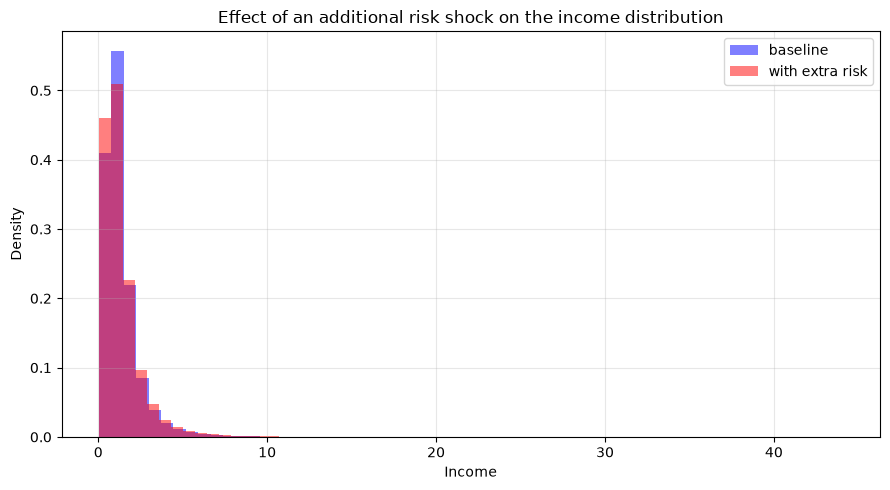

In [46]:
extra_risk_sd = 0.30
rng = np.random.default_rng(2024)
extra_shock = rng.lognormal(mean=-0.5 * extra_risk_sd**2, sigma=extra_risk_sd, size=income.shape)
extended_income = income * extra_shock

baseline_gini = gini(income.ravel())
extended_gini = gini(extended_income.ravel())
print(f'\nExtra-risk extension: baseline pooled Gini = {baseline_gini:.3f}; extended pooled Gini = {extended_gini:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(income.ravel(), bins=60, density=True, alpha=0.5, color='blue', label='baseline')
ax.hist(extended_income.ravel(), bins=60, density=True, alpha=0.5, color='red', label='with extra risk')
ax.set_title('Effect of an additional risk shock on the income distribution')
ax.set_xlabel('Income')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()